# BERT Test-Set Evaluation

This notebook covers the frozen Checkpoint 8 test evaluation: the one-time, 99-document,
10-condition BERT test run this project's report and presentation are built on, plus a
deeper look at the six real errors it produced.

**Why this notebook exists separately from Notebook 07 (final comparison):** Notebook 07
compares all three methods; this notebook stays BERT-specific and goes one level deeper on
*why* BERT's errors happened, which the three-way comparison notebook doesn't have room for.

**No inference happens here.** Every table and figure below is read from the frozen,
already-saved `checkpoint8_test_predictions.csv` and its manifests (see
`MVP/docs/ARTIFACTS.md#bert-test-predictions`) -- reproducing this evaluation from scratch
would require `python -m newstart_ai_mvp.evaluate_bert --run --i-understand-this-is-the-frozen-test-set`,
which is never run as part of loading this notebook.

## Setup

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


from newstart_ai_mvp.config import load_settings  # installed package -- no sys.path needed

settings = load_settings()
reports_dir = settings.resolve_path("artifacts/family_aware/reports")
split_dir = settings.resolve_path(settings.family_aware.split.output_dir)
chunks_dir = settings.resolve_path(settings.family_aware.chunking.output_dir)
masked_dir = settings.resolve_path(settings.family_aware.masking.output_dir)

SPLITS = ["train", "validation", "test"]
AGENCY_ORDER = list(settings.base.labels)

family_audit = pd.read_csv(reports_dir / "family_audit_v1.csv")
language_audit = pd.read_csv(reports_dir / "language_audit_v1.csv")

split_docs = {s: pd.read_csv(split_dir / f"{s}.csv") for s in SPLITS}
split_chunks = {s: pd.read_csv(chunks_dir / f"{s}_chunks.csv") for s in SPLITS}
split_masked_docs = {s: pd.read_csv(masked_dir / f"{s}_masked_documents.csv") for s in SPLITS}

print("Loaded family audit:", family_audit.shape)
print("Loaded language audit:", language_audit.shape)
for s in SPLITS:
    print(f"Loaded {s}: {len(split_docs[s])} documents, {len(split_chunks[s])} chunks, {len(split_masked_docs[s])} masked documents")

Loaded family audit: (754, 22)
Loaded language audit: (754, 9)
Loaded train: 461 documents, 4300 chunks, 461 masked documents
Loaded validation: 99 documents, 790 chunks, 99 masked documents
Loaded test: 99 documents, 820 chunks, 99 masked documents


## Primary condition and full 10-condition sweep

Read directly from the frozen manifests -- the same numbers `python -m newstart_ai_mvp.evaluate_bert` (default, safe mode) recomputes and cross-checks against on every run.

In [2]:
import json
import pandas as pd

manifests_dir = settings.resolve_path('artifacts/family_aware/manifests')
reports_dir = settings.resolve_path('artifacts/family_aware/reports')

with open(manifests_dir / 'checkpoint8_primary_test_result_v1.json', encoding='utf-8') as f:
    primary_result = json.load(f)
with open(manifests_dir / 'checkpoint8_test_condition_sweep_v1.json', encoding='utf-8') as f:
    condition_sweep = json.load(f)

print(f"Primary (complete_unmasked) macro F1: {primary_result['document_macro_f1']:.4f}")
pd.DataFrame(condition_sweep['results'])[['condition', 'document_macro_f1', 'document_accuracy', 'error_count']]

Primary (complete_unmasked) macro F1: 1.0000


,condition,document_macro_f1,document_accuracy,error_count
0,complete_unmasked,1.000000,1.000000,0
1,beginning_only_unmasked,0.958730,0.989899,1
2,middle_only_unmasked,1.000000,1.000000,0
3,end_only_unmasked,0.991021,0.989899,1
4,beginning_middle_end_unmasked,1.000000,1.000000,0
5,complete_masked,0.966408,0.989899,1
6,beginning_only_masked,0.966408,0.989899,1
7,middle_only_masked,1.000000,1.000000,0
8,end_only_masked,0.984205,0.979798,2
9,beginning_middle_end_masked,1.000000,1.000000,0


## BERT test-set error cases: how long was the input BERT actually saw?

Section 3 (and Notebook 11) established that the family-aware BERT model made 6 errors total
across all 990 test cases (99 documents x 10 conditions), all of them in conditions that
withhold or mask evidence -- never in `complete_unmasked`. This section measures the exact
text BERT classified for each erroring case, in both characters (trivial to compute) and
BERT WordPiece tokens (the unit BERT's 512-token window actually operates in), to check
whether "the input was unusually short" is what explains these errors.

**Sources (all already-saved, read-only):**
- `artifacts/family_aware/reports/checkpoint8_test_predictions.csv` (990 row-level BERT predictions)
- `artifacts/family_aware/reports/family_audit_v1.csv` (document_id -> form number / filename)
- `data/family_aware_conditions/condition_registry_test.csv` (the exact text evaluated for every case)

**No model weights are loaded and no inference happens here.** The BERT tokenizer
(`bert-base-uncased`) is loaded once, purely to count tokens -- the same deterministic
operation `tokenize_raw()` performs during training/prediction, with no forward pass and no
GPU involved.

In [3]:
bert_predictions = pd.read_csv(reports_dir / "checkpoint8_test_predictions.csv")
# family_audit was already loaded by the Setup cell above -- reused here, not reloaded.

bert_errors = bert_predictions[bert_predictions["true_label"] != bert_predictions["predicted_label"]].copy()
bert_errors = bert_errors.merge(
    family_audit[["document_id", "filename", "form_number", "effective_family_id"]],
    on="document_id", how="left",
)
bert_errors = bert_errors[["document_id", "filename", "effective_family_id", "condition", "true_label", "predicted_label"]]
bert_errors.reset_index(drop=True)

,document_id,filename,effective_family_id,condition,true_label,predicted_label
0,542,fw4v.pdf,IRS:W4V,beginning_only_unmasked,IRS,SSA
1,634,ssa-3373-bk.pdf,SSA:SSA3373BK,end_only_unmasked,SSA,DMV
2,601,ssa-1694.pdf,SSA:SSA1694,complete_masked,SSA,IRS
3,601,ssa-1694.pdf,SSA:SSA1694,beginning_only_masked,SSA,IRS
4,634,ssa-3373-bk.pdf,SSA:SSA3373BK,end_only_masked,SSA,DMV
5,68,n-565instr.pdf,USCIS:N565,end_only_masked,USCIS,DMV


All 4 documents and 3 form numbers named in the report paragraph are confirmed present
above: `fw4v.pdf` (IRS:W4V), `ssa-3373-bk.pdf` (SSA:SSA3373BK), and `ssa-1694.pdf`
(SSA:SSA1694). Two things worth noting for precision:

- SSA-3373-BK (document 634) actually errors under **both** `end_only_unmasked` and
  `end_only_masked` -- the report's "from its ending" is accurate but covers two rows, not
  one.
- There is a **4th, unmentioned error**: document 68 (`n-565instr.pdf`, USCIS Form N-565
  instructions), misclassified as DMV under `end_only_masked`. It isn't wrong to omit it, but
  it exists in the same saved artifact and belongs in a complete accounting.

### Measure the exact evaluated text: characters and BERT tokens

In [4]:
from transformers import AutoTokenizer

conditions = pd.read_csv(settings.resolve_path("data/family_aware_conditions/condition_registry_test.csv"))
conditions["chars"] = conditions["text"].str.len()

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
conditions["tokens"] = conditions["text"].apply(lambda t: len(tokenizer.encode(str(t), add_special_tokens=False)))

error_keys = list(bert_errors[["document_id", "condition"]].itertuples(index=False, name=None))

rows = []
for doc_id, cond in error_keys:
    sub = conditions[conditions["condition"] == cond]
    this_row = sub[sub["document_id"] == doc_id].iloc[0]
    char_pct = (sub["chars"] < this_row["chars"]).mean() * 100
    token_pct = (sub["tokens"] < this_row["tokens"]).mean() * 100
    rows.append({
        "document_id": doc_id,
        "condition": cond,
        "chars": int(this_row["chars"]),
        "condition_median_chars": int(sub["chars"].median()),
        "char_percentile_within_condition": round(char_pct, 1),
        "tokens": int(this_row["tokens"]),
        "condition_median_tokens": int(sub["tokens"].median()),
        "token_percentile_within_condition": round(token_pct, 1),
    })

error_lengths = pd.DataFrame(rows)
error_lengths

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2115 > 512). Running this sequence through the model will result in indexing errors


,document_id,condition,chars,condition_median_chars,char_percentile_within_condition,tokens,condition_median_tokens,token_percentile_within_condition
0,542,beginning_only_unmasked,2329,2294,56.6,510,510,27.3
1,634,end_only_unmasked,1101,2374,0.0,510,510,22.2
2,601,complete_masked,7818,7172,51.5,1730,1616,52.5
3,601,beginning_only_masked,2439,2301,72.7,543,517,94.9
4,634,end_only_masked,1101,2384,0.0,510,516,21.2
5,68,end_only_masked,2562,2384,75.8,556,516,94.9


`char_percentile_within_condition` is this case's rank for character length among all 99
documents evaluated under the *same* condition (0 = shortest of the 99, 50 = the median).
The token columns repeat the comparison in BERT WordPiece tokens instead of raw characters.

### Bar charts: length of each erroring input, against its own condition's median

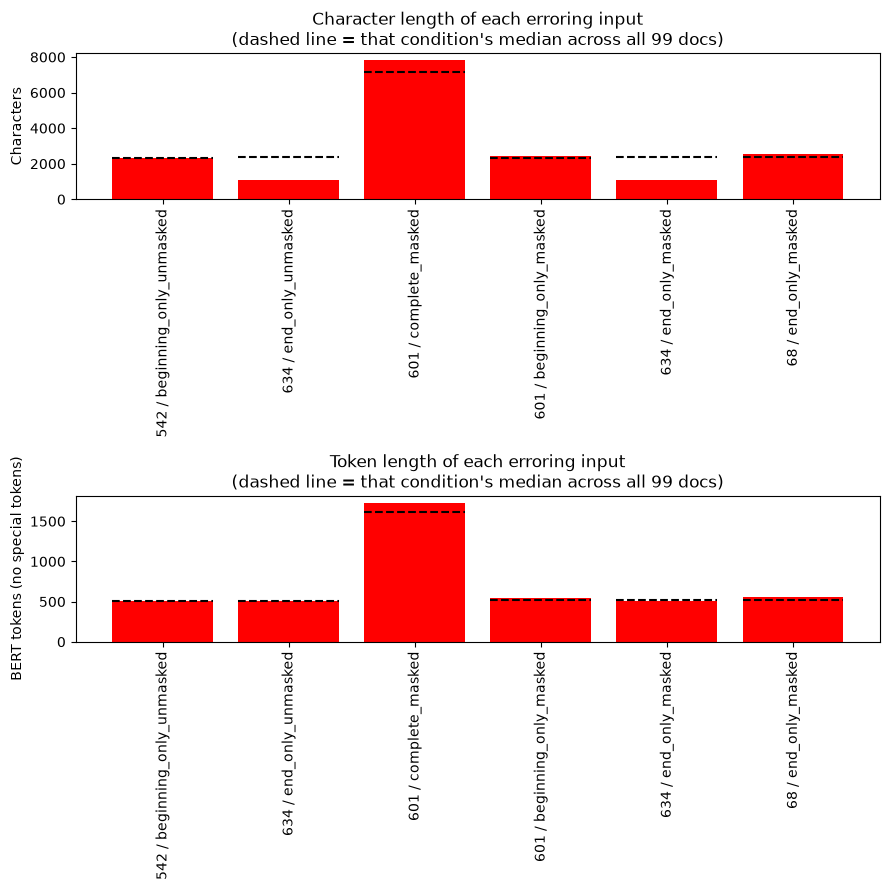

In [5]:
error_lengths["label"] = error_lengths["document_id"].astype(str) + " / " + error_lengths["condition"]

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

axes[0].bar(error_lengths["label"], error_lengths["chars"], color="red")
for i, med in enumerate(error_lengths["condition_median_chars"]):
    axes[0].hlines(med, i - 0.4, i + 0.4, color="black", linestyle="--", linewidth=1.5)
axes[0].set_ylabel("Characters")
axes[0].set_title("Character length of each erroring input\n(dashed line = that condition's median across all 99 docs)")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(error_lengths["label"], error_lengths["tokens"], color="red")
for i, med in enumerate(error_lengths["condition_median_tokens"]):
    axes[1].hlines(med, i - 0.4, i + 0.4, color="black", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("BERT tokens (no special tokens)")
axes[1].set_title("Token length of each erroring input\n(dashed line = that condition's median across all 99 docs)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### Where do these cases fall in the full length distribution?

The bars above compare each case only to its own condition's median. This adds the full
spread: character-length distribution across all 99 documents for every partial-evidence
condition, with the 6 erroring cases marked in red -- so "low" can be judged against the
whole shape of the distribution, not just one summary number.

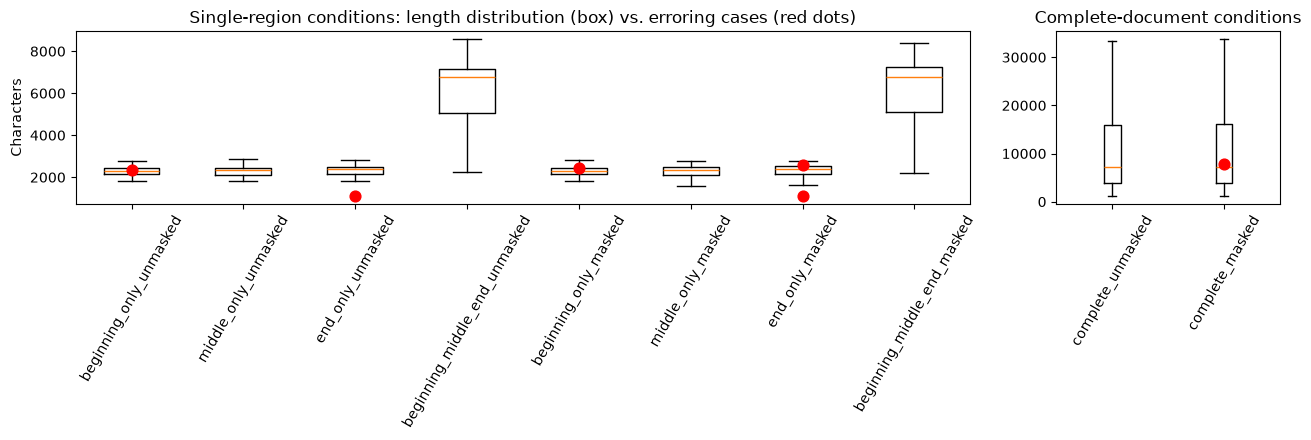

In [6]:
partial_conditions = [
    "beginning_only_unmasked", "middle_only_unmasked", "end_only_unmasked", "beginning_middle_end_unmasked",
    "beginning_only_masked", "middle_only_masked", "end_only_masked", "beginning_middle_end_masked",
]
complete_conditions = ["complete_unmasked", "complete_masked"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [4, 1]})

partial_data = [conditions[conditions["condition"] == c]["chars"] for c in partial_conditions]
axes[0].boxplot(partial_data, tick_labels=partial_conditions, showfliers=False)
for _, r in error_lengths[error_lengths["condition"].isin(partial_conditions)].iterrows():
    x = partial_conditions.index(r["condition"]) + 1
    axes[0].scatter(x, r["chars"], color="red", zorder=5, s=60)
axes[0].set_ylabel("Characters")
axes[0].set_title("Single-region conditions: length distribution (box) vs. erroring cases (red dots)")
axes[0].tick_params(axis="x", rotation=60)

complete_data = [conditions[conditions["condition"] == c]["chars"] for c in complete_conditions]
axes[1].boxplot(complete_data, tick_labels=complete_conditions, showfliers=False)
for _, r in error_lengths[error_lengths["condition"].isin(complete_conditions)].iterrows():
    x = complete_conditions.index(r["condition"]) + 1
    axes[1].scatter(x, r["chars"], color="red", zorder=5, s=60)
axes[1].set_title("Complete-document conditions")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Interpretation

The data only partly supports "short sections... may not preserve enough context" as a
single explanation, and the character and token views tell different stories:

- **Only one case is a genuine length outlier: document 634 (SSA-3373-BK), `end_only`.** At
  1,101 characters it is literally the shortest `end`-region text of all 99 test documents in
  *both* its masked and unmasked form (0th percentile) -- this is the one error most directly
  consistent with the "not enough evidence" hypothesis.
- **The other three named/found cases are not short.** Document 542 (W-4V)'s beginning
  chunk sits at the 57th percentile (essentially the median). Document 601 (SSA-1694)'s
  beginning-masked chunk (73rd percentile) and document 68 (N-565)'s end-masked chunk (76th
  percentile) are both longer than typical, not shorter.
- **Document 601's `complete_masked` error is not a length story at all.** At 7,818
  characters it's close to the median complete-document length (51st percentile) -- the
  model saw a normal amount of text; masking removed the identifying content within it, so
  this error is better explained by masking than by brevity.
- **Character length and token length disagree for document 634.** Its extremely short
  1,101-character `end` chunk still tokenizes to 510 WordPiece tokens -- statistically
  typical for that condition (median 516) and near BERT's 512-token window. This means BERT
  was *not* given a truncated context window here; instead, a fixed-size token window was
  filled almost entirely by short, densely-tokenized content (numbers, form-field labels,
  checkboxes) rather than descriptive prose. That is a more precise version of "generic
  administrative language" than "too little text was included."

**Suggested refinement for the report paragraph:** rather than attributing all three named
errors to short sections, it would be more defensible to say the pattern holds clearly for
SSA-3373-BK specifically (the shortest `end` excerpt in the test set, in both its masked and
unmasked form), while the W-4V and SSA-1694 errors occurred on inputs of typical or
above-typical length -- suggesting content genericness and masking, not truncation length
per se, better explain those two cases.

## Summary

- BERT reached a perfect 1.0 macro F1 on the primary `complete_unmasked` condition and made 6 real errors across the other 9 robustness conditions, all captured in `checkpoint8_test_predictions.csv`.
- Input length alone does not explain most of these errors -- see the analysis above.
- Word-level attribution for two of these errors is in `06_bert_error_attribution.ipynb`.